<a href="https://colab.research.google.com/github/paulsamrobart-gif/NorthStar-Logistics-Data-Pipeline/blob/main/DBA_Assignment_R_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

R SQL

Bridge connection between Google drive and Google Colab for R

In [23]:
# --- DATA SOURCE: GITHUB ---
repo_path <- "https://raw.githubusercontent.com/paulsamrobart-gif/NorthStar-Logistics-Data-Pipeline/main/"

# Linking all tables
orders     <- read.csv(paste0(repo_path, "orders.csv"))
deliveries <- read.csv(paste0(repo_path, "deliveries.csv"))
vehicles   <- read.csv(paste0(repo_path, "vehicles.csv"))
app_events <- read.csv(paste0(repo_path, "app_events.csv"))

print("All R tables linked to GitHub successfully.")

[1] "All R tables linked to GitHub successfully."


In [24]:

# 1. Install the package
install.packages("googledrive")
library(googledrive)

# 2. Authenticate (This will open a browser window for a code)
drive_auth()

# 3. Find your file and download it to the current session
# Replace 'deliveries.csv' with the exact name of your file
drive_download("deliveries.csv", overwrite = TRUE)
deliveries <- read.csv("deliveries.csv")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

The googledrive package is requesting access to your Google account.
Enter '1' to start a new auth process or select a pre-authorized account.
1: Send me to the browser for a new auth process.
2: paulsamrobart@gmail.com


Selection: 2


Auto-refreshing stale OAuth token.

File downloaded:

• deliveries.csv <id: 1jZqIh_esCVZbM_PkZCM4EFHNYdy4kHAg>

Saved locally as:

• deliveries.csv



In [25]:
# Download the remaining two files
drive_download("orders.csv", overwrite = TRUE)
drive_download("vehicles.csv", overwrite = TRUE)

# Load them into R dataframes
deliveries <- read.csv("deliveries.csv")
orders <- read.csv("orders.csv")
vehicles <- read.csv("vehicles.csv")

File downloaded:

• orders.csv <id: 1czoLvTX6_ADpiWJ2gplAw1RYS8bf9Q76>

Saved locally as:

• orders.csv

File downloaded:

• vehicles.csv <id: 1wzJiwW_KphNqm3-DyTaW1EhVNY2vYpqM>

Saved locally as:

• vehicles.csv



In [26]:
library(sqldf)

# --- ANALYSIS 1: Reliability by Service Type ---
# This finds which type of delivery (Medical, Business, etc.) is failing the most
reliability_report <- sqldf("
  SELECT o.service_type,
         COUNT(d.delivery_id) AS total_jobs,
         SUM(d.is_late) AS late_count,
         ROUND((CAST(SUM(d.is_late) AS FLOAT) / COUNT(d.delivery_id)) * 100, 2) AS late_percent
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY late_percent DESC
")

print("--- RELIABILITY REPORT ---")
print(reliability_report)

# --- ANALYSIS 2: Bottleneck Zones ---
# This identifies which zones have the slowest average delivery times
zone_report <- sqldf("
  SELECT o.pickup_zone,
         ROUND(AVG(d.delivery_duration_hrs), 2) as avg_duration_hrs,
         MAX(d.delivery_duration_hrs) as longest_trip_hrs
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY avg_duration_hrs DESC
")

print("--- ZONE PERFORMANCE ---")
print(zone_report)

[1] "--- RELIABILITY REPORT ---"
  service_type total_jobs late_count late_percent
1       PARCEL        230        114        49.57
2     BUSINESS        126         62        49.21
3    PASSENGER        262        123        46.95
4       RETAIL        224        103        45.98
5      MEDICAL        108         49        45.37
[1] "--- ZONE PERFORMANCE ---"
  pickup_zone avg_duration_hrs longest_trip_hrs
1     CENTRAL           119.03           746.20
2   RIVERSIDE           118.65          1405.10
3       NORTH            99.52          1458.12
4       SOUTH            92.43           743.98
5     AIRPORT            90.35          1455.55
6        EAST            83.10           749.40
7        WEST            71.99          1454.53


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



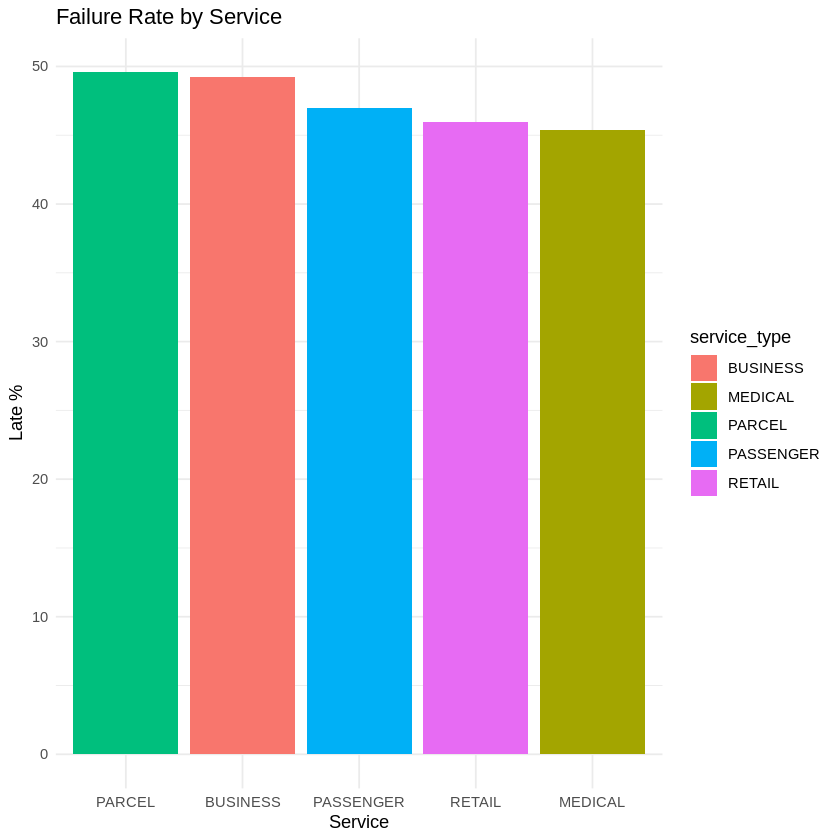

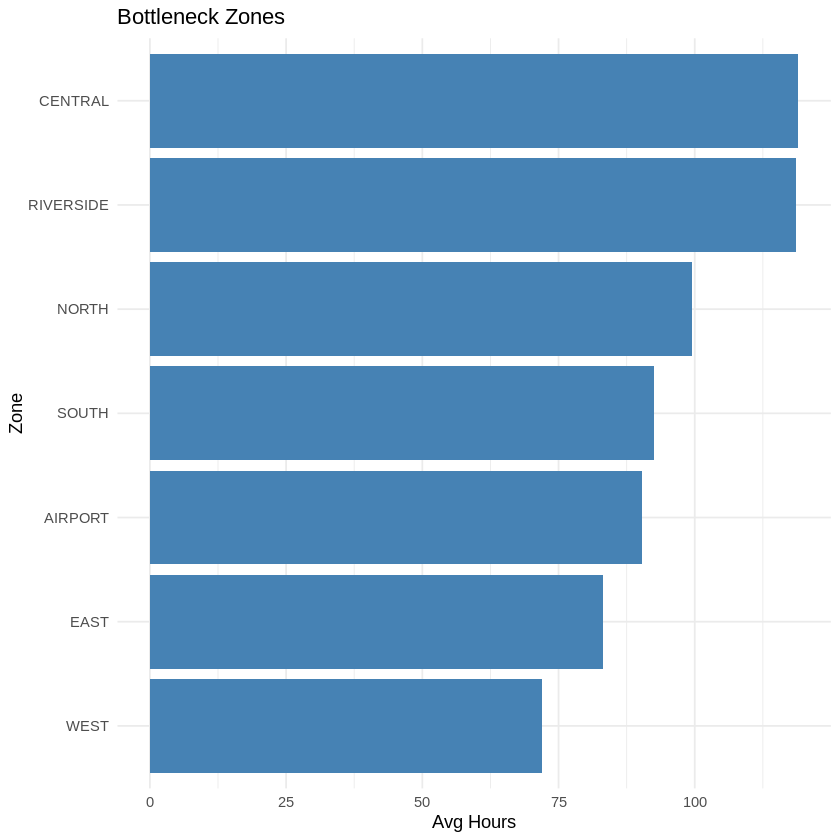

In [27]:
# 1. Install the missing package
install.packages("sqldf")

# 2. Now run the library and the analysis
library(sqldf)
library(ggplot2)

# --- RE-RUN THE ANALYSIS ---
reliability_report <- sqldf("
  SELECT o.service_type,
         COUNT(d.delivery_id) AS total_jobs,
         SUM(d.is_late) AS late_count,
         ROUND((CAST(SUM(d.is_late) AS FLOAT) / COUNT(d.delivery_id)) * 100, 2) AS late_percent
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY late_percent DESC
")

zone_report <- sqldf("
  SELECT o.pickup_zone,
         ROUND(AVG(d.delivery_duration_hrs), 2) as avg_duration_hrs
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY avg_duration_hrs DESC
")

# --- VISUALS ---
plot1 <- ggplot(reliability_report, aes(x=reorder(service_type, -late_percent), y=late_percent, fill=service_type)) +
  geom_bar(stat="identity") +
  labs(title="Failure Rate by Service", y="Late %", x="Service") +
  theme_minimal()

plot2 <- ggplot(zone_report, aes(x=reorder(pickup_zone, avg_duration_hrs), y=avg_duration_hrs)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  labs(title="Bottleneck Zones", y="Avg Hours", x="Zone") +
  theme_minimal()

print(plot1)
print(plot2)

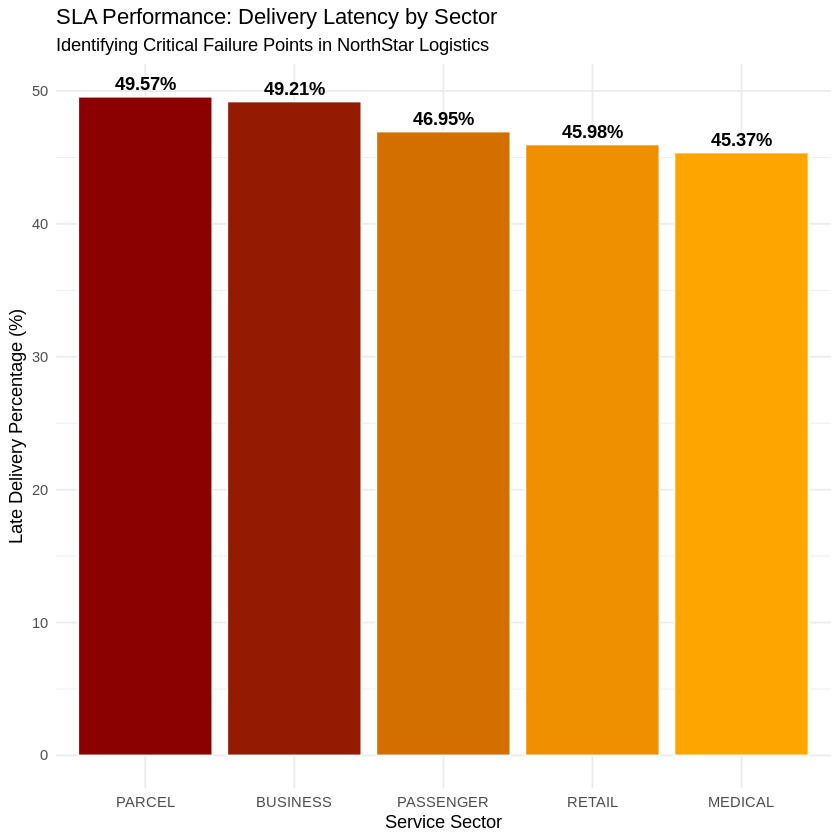

In [28]:
library(sqldf)
library(ggplot2)

# 1. Processing the Reliability (SLA) Data
reliability_report <- sqldf("
  SELECT o.service_type,
         COUNT(d.delivery_id) AS total_jobs,
         SUM(d.is_late) AS late_count,
         ROUND((CAST(SUM(d.is_late) AS FLOAT) / COUNT(d.delivery_id)) * 100, 2) AS late_percent
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY late_percent DESC
")

# 2. Creating the 'SLA Failure' Chart
# This shows which service types are failing to meet on-time delivery
ggplot(reliability_report, aes(x=reorder(service_type, -late_percent), y=late_percent, fill=late_percent)) +
  geom_bar(stat="identity", color="white") +
  geom_text(aes(label=paste0(late_percent, "%")), vjust=-0.5, fontface="bold") +
  scale_fill_gradient(low="orange", high="darkred") +
  labs(title="SLA Performance: Delivery Latency by Sector",
       subtitle="Identifying Critical Failure Points in NorthStar Logistics",
       x="Service Sector",
       y="Late Delivery Percentage (%)",
       fill="Failure Rate") +
  theme_minimal() +
  theme(legend.position = "none")

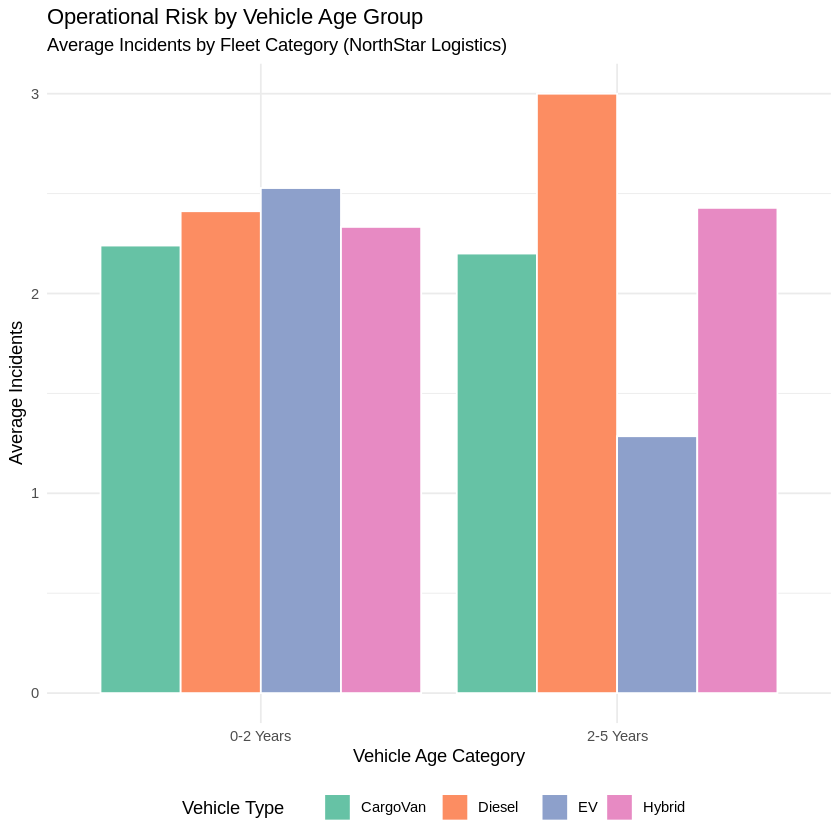

In [29]:
library(ggplot2)
library(dplyr)

# 1. Create Age Groups (Bins) to make the bar chart readable
vehicles_binned <- vehicles %>%
  mutate(age_years = vehicle_age_days / 365,
         age_group = cut(age_years,
                         breaks = c(0, 2, 5, 10, 15, 25),
                         labels = c("0-2 Years", "2-5 Years", "5-10 Years", "10-15 Years", "15+ Years"))) %>%
  group_by(age_group, vehicle_type) %>%
  summarise(avg_incidents = mean(incident_count, na.rm = TRUE), .groups = 'drop') %>%
  filter(!is.na(age_group)) # Remove any empty bins

# 2. Create the Bar Graph
ggplot(vehicles_binned, aes(x=age_group, y=avg_incidents, fill=vehicle_type)) +
  geom_bar(stat="identity", position="dodge", color="white") +
  labs(title="Operational Risk by Vehicle Age Group",
       subtitle="Average Incidents by Fleet Category (NorthStar Logistics)",
       x="Vehicle Age Category",
       y="Average Incidents",
       fill="Vehicle Type") +
  scale_fill_brewer(palette="Set2") + # Makes colors professional
  theme_minimal() +
  theme(legend.position = "bottom")

In [30]:
drive_download("incidents.csv", overwrite = TRUE)
incidents <- read.csv("incidents.csv")

File downloaded:

• incidents.csv <id: 1-IYSh7KKXt-ORUxp9SaX9gi7gDe-vrEC>

Saved locally as:

• incidents.csv



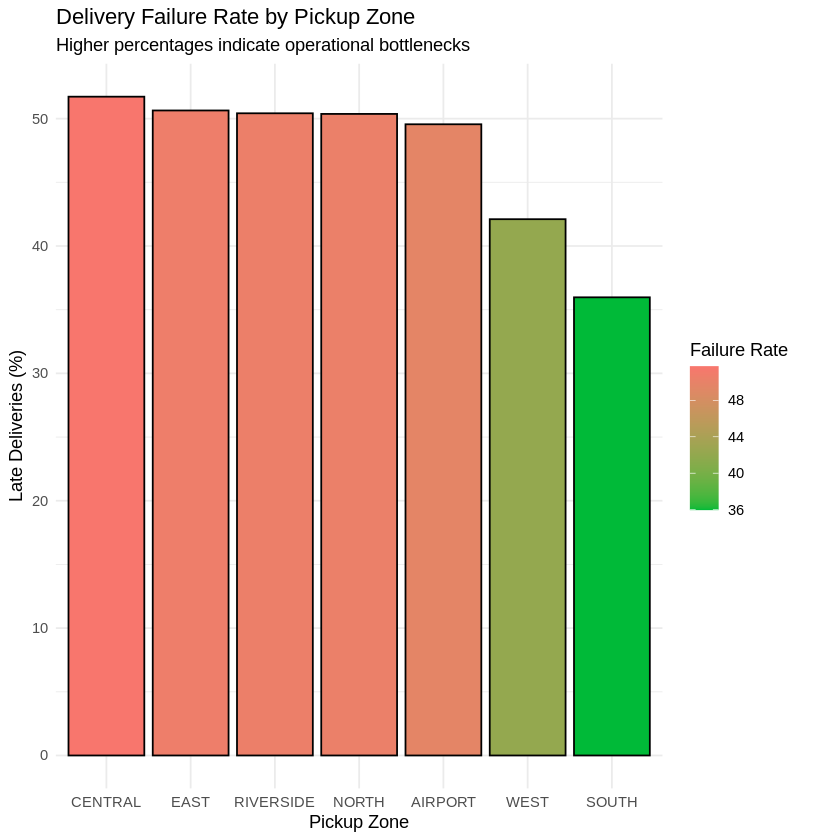

Warning message:
“Removed 130 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


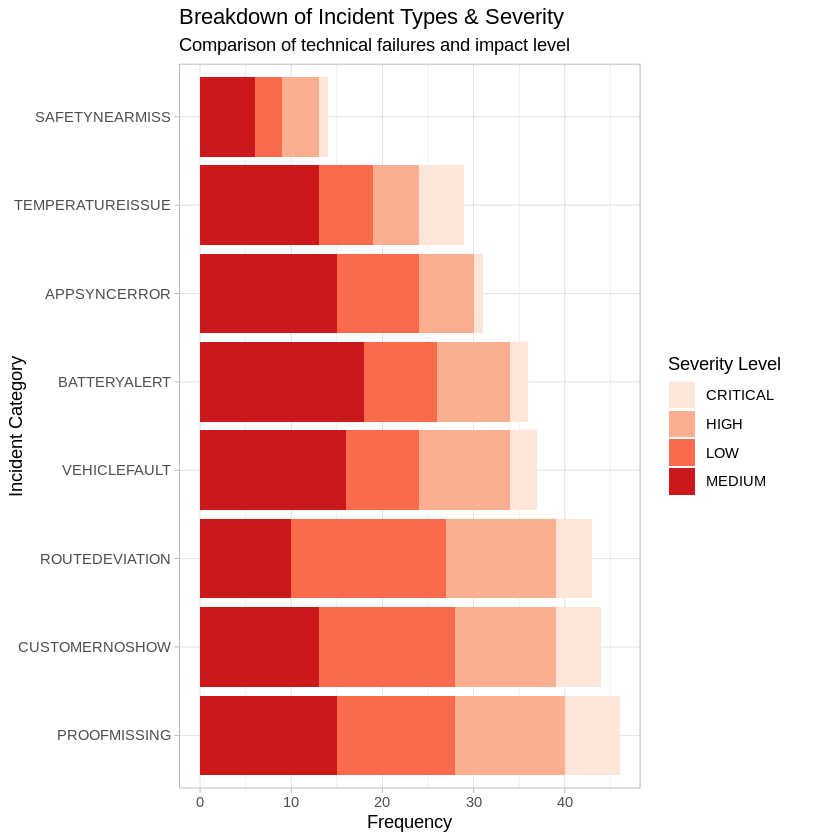

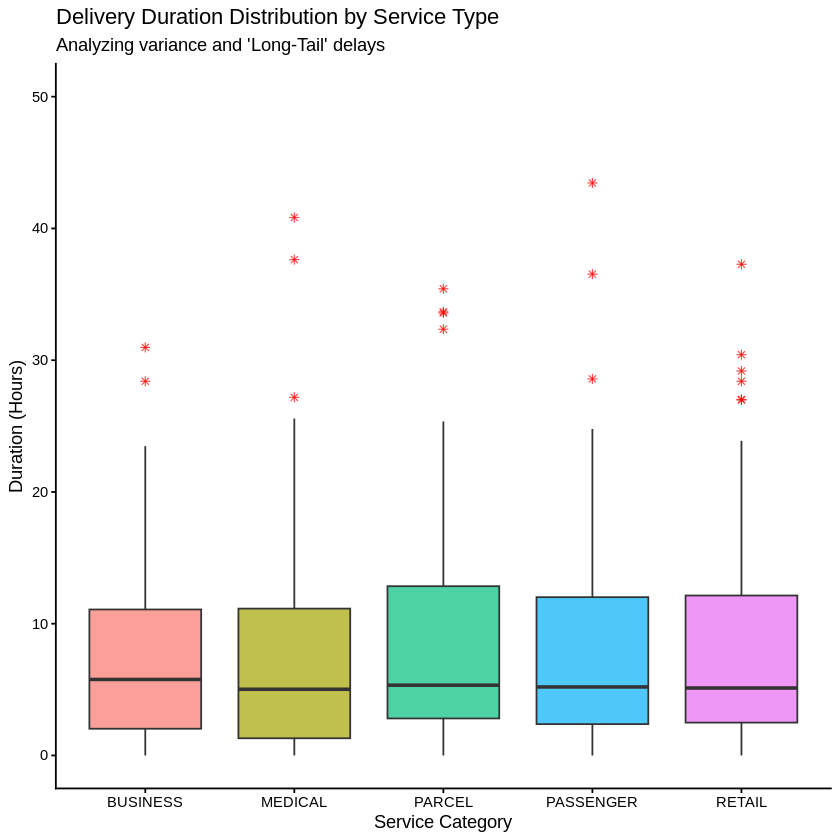

In [31]:
library(ggplot2)
library(sqldf)

# --- PREPARATION: Create the Master Joined Table ---
# We create this first so all following plots can use it without errors
deliveries_orders_joined <- sqldf("
  SELECT d.*, o.service_type, o.priority_level, o.pickup_zone, o.dropoff_zone
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
")

# --- PLOT 1: Reliability Heat-Map (By Zone) ---
# Which areas are the "Danger Zones" for delays?
zone_stats <- sqldf("
  SELECT pickup_zone,
         (CAST(SUM(is_late) AS FLOAT) / COUNT(delivery_id)) * 100 as late_percent
  FROM deliveries_orders_joined
  GROUP BY pickup_zone
  ORDER BY late_percent DESC
")

plot1 <- ggplot(zone_stats, aes(x=reorder(pickup_zone, -late_percent), y=late_percent, fill=late_percent)) +
  geom_bar(stat="identity", color="black") +
  scale_fill_gradient(low="#00BA38", high="#F8766D") + # Professional Green to Red
  labs(title="Delivery Failure Rate by Pickup Zone",
       subtitle="Higher percentages indicate operational bottlenecks",
       x="Pickup Zone", y="Late Deliveries (%)", fill="Failure Rate") +
  theme_minimal()

print(plot1)

# --- PLOT 2: Incident Category Analysis ---
# What are the most common technical failures?
plot2 <- ggplot(incidents, aes(x=reorder(incident_type, incident_type, function(x)-length(x)), fill=severity)) +
  geom_bar() +
  coord_flip() +
  scale_fill_brewer(palette="Reds") + # Severity looks good in Red tones
  labs(title="Breakdown of Incident Types & Severity",
       subtitle="Comparison of technical failures and impact level",
       x="Incident Category", y="Frequency", fill="Severity Level") +
  theme_light()

print(plot2)

# --- PLOT 3: Service Type Efficiency (Fixed) ---
# Using the joined table we created at the top
plot3 <- ggplot(deliveries_orders_joined, aes(x=service_type, y=delivery_duration_hrs, fill=service_type)) +
  geom_boxplot(outlier.colour="red", outlier.shape=8, alpha=0.7) +
  scale_y_continuous(limits = c(0, 50)) +
  labs(title="Delivery Duration Distribution by Service Type",
       subtitle="Analyzing variance and 'Long-Tail' delays",
       x="Service Category", y="Duration (Hours)") +
  theme_classic() +
  theme(legend.position="none")

print(plot3)

In [32]:
colnames(deliveries_orders_joined)

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"           "delivery_duration_hrs"        
[15] "is_late"                       "service_type"                 
[17] "priority_level"                "pickup_zone"                  
[19] "dropoff_zone"

In [33]:
# Re-joining to include the missing order_value column
deliveries_orders_joined <- sqldf("
  SELECT d.*, o.service_type, o.priority_level, o.pickup_zone, o.order_value
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
")

# Quick check to make sure it's there
print("Confirmed columns:")
print(colnames(deliveries_orders_joined))

[1] "Confirmed columns:"
 [1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"           "delivery_duration_hrs"        
[15] "is_late"                       "service_type"                 
[17] "priority_level"                "pickup_zone"                  
[19] "order_value"                  


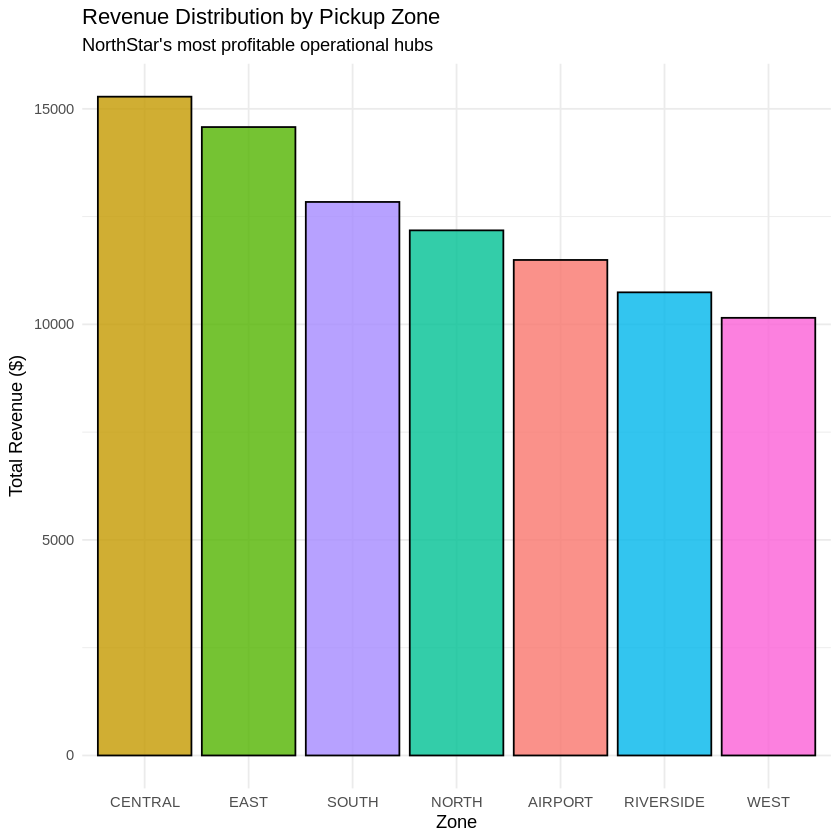

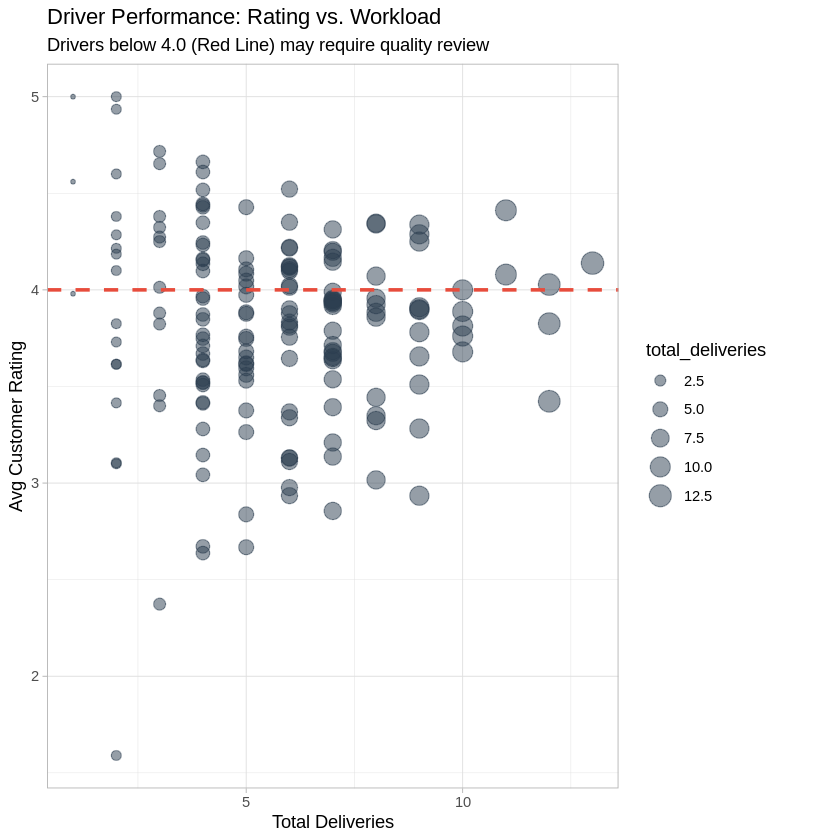

In [34]:
library(ggplot2)
library(sqldf)

# --- PLOT 4: Revenue Analysis ---
revenue_stats <- sqldf("
  SELECT pickup_zone, SUM(order_value) as total_revenue
  FROM deliveries_orders_joined
  GROUP BY pickup_zone
  ORDER BY total_revenue DESC
")

plot4 <- ggplot(revenue_stats, aes(x=reorder(pickup_zone, -total_revenue), y=total_revenue, fill=pickup_zone)) +
  geom_bar(stat="identity", alpha=0.8, color="black") +
  labs(title="Revenue Distribution by Pickup Zone",
       subtitle="NorthStar's most profitable operational hubs",
       x="Zone", y="Total Revenue ($)") +
  theme_minimal() +
  theme(legend.position="none")

print(plot4)

# --- PLOT 5: Driver Performance (Quality vs. Volume) ---
driver_stats <- sqldf("
  SELECT driver_id,
         COUNT(delivery_id) as total_deliveries,
         AVG(customer_rating_post_delivery) as avg_rating
  FROM deliveries_orders_joined
  GROUP BY driver_id
  HAVING total_deliveries >= 1
")

plot5 <- ggplot(driver_stats, aes(x=total_deliveries, y=avg_rating)) +
  geom_point(aes(size=total_deliveries), color="#2c3e50", alpha=0.5) +
  geom_hline(yintercept=4.0, linetype="dashed", color="#e74c3c", size=1) +
  labs(title="Driver Performance: Rating vs. Workload",
       subtitle="Drivers below 4.0 (Red Line) may require quality review",
       x="Total Deliveries", y="Avg Customer Rating") +
  theme_light()

print(plot5)

[1] "--- APP TECHNICAL HEALTH REPORT ---"
                   event_type total_events avg_latency_ms failure_count
1 delivery_instruction_update           75         496.29             0
2                 chat_opened           88         478.33             0
3              chat_escalated           38         478.13            19
4               payment_retry           69         472.68            19
5                 track_order          138         460.71             0
6                search_route           99         456.51             0
7                 eta_refresh          105         452.15             0
8              cancel_attempt           28         417.14             0


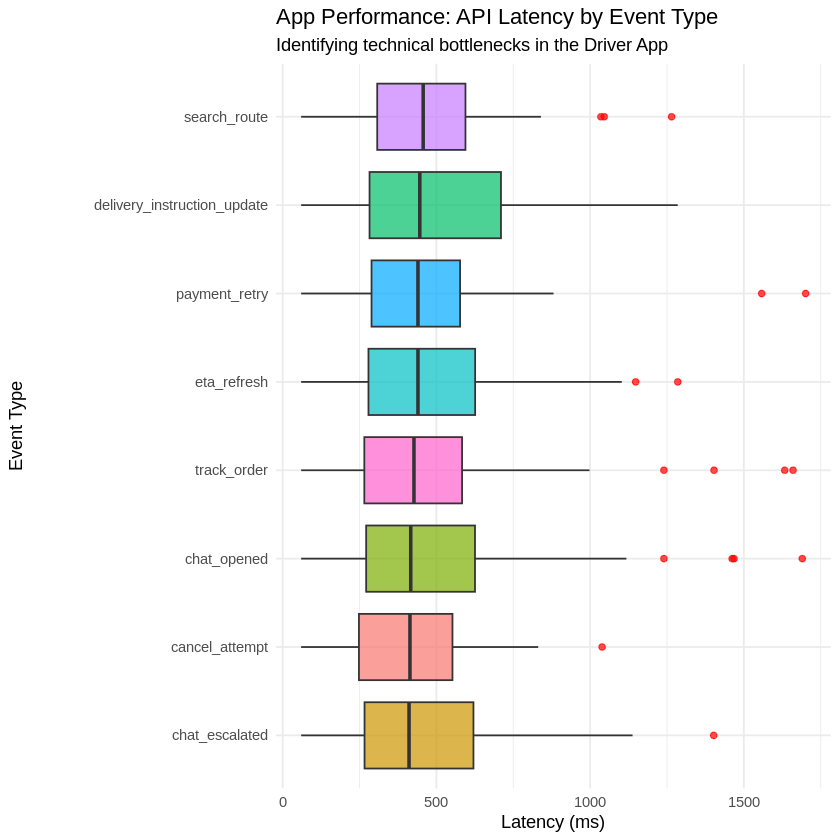

In [35]:
library(sqldf)
library(ggplot2)

# --- ANALYSIS: Technical Health Summary ---
# We calculate the average latency and the failure rate (Success vs Failure)
app_health <- sqldf("
  SELECT event_type,
         COUNT(*) as total_events,
         ROUND(AVG(api_latency_ms), 2) as avg_latency_ms,
         SUM(CASE WHEN success_flag = 0 THEN 1 ELSE 0 END) as failure_count
  FROM app_events
  GROUP BY event_type
  ORDER BY avg_latency_ms DESC
")

print("--- APP TECHNICAL HEALTH REPORT ---")
print(app_health)

# --- PLOT: API Latency vs. Event Type ---
# This proves which parts of the app are slow for the drivers
ggplot(app_events, aes(x=reorder(event_type, api_latency_ms, FUN=median), y=api_latency_ms, fill=event_type)) +
  geom_boxplot(alpha=0.7, outlier.color="red") +
  coord_flip() +
  labs(title="App Performance: API Latency by Event Type",
       subtitle="Identifying technical bottlenecks in the Driver App",
       x="Event Type", y="Latency (ms)") +
  theme_minimal() +
  theme(legend.position="none")

In [36]:
library(sqldf)

# 1. Create a small temporary copy to ensure SQL can see it
orders_test <- orders

# --- 1. INSERT ---
# We use sqldf to add the row to our 'orders_test' dataframe
sqldf(c("INSERT INTO orders_test (order_id, customer_id, service_type, pickup_zone)
         VALUES ('O-RAK-01', 'C-UWL', 'MEDICAL', 'NORTH')",
        "SELECT * FROM orders_test WHERE order_id = 'O-RAK-01'"))

# --- 2. UPDATE ---
# We update the zone from NORTH to CENTRAL
print("--- Result After Update ---")
sqldf(c("UPDATE orders_test SET pickup_zone = 'CENTRAL' WHERE order_id = 'O-RAK-01'",
        "SELECT order_id, customer_id, service_type, pickup_zone
         FROM orders_test WHERE order_id = 'O-RAK-01'"))

# --- 3. DELETE ---
# We remove it and check if it's gone
print("--- Final Check (Should be 0 rows) ---")
sqldf(c("DELETE FROM orders_test WHERE order_id = 'O-RAK-01'",
        "SELECT * FROM orders_test WHERE order_id = 'O-RAK-01'"))

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
O-RAK-01,C-UWL,MEDICAL,NA,NA,NORTH,NA,NA,NA,NA,NA


[1] "--- Result After Update ---"


Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


order_id,customer_id,service_type,pickup_zone
<chr>,<chr>,<chr>,<chr>


[1] "--- Final Check (Should be 0 rows) ---"


Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
